# Installation

In [ ]:
%pip install -q pytz

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

# ── Edit this to match where your TOX folder lives in Drive ──────
DRIVE_ROOT = DRIVE_ROOT = '/content/drive/MyDrive/Research/HybridGNN/TOX'
os.makedirs(f'{DRIVE_ROOT}/checkpoints_tox21', exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/results_tox21',exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/Analysis', exist_ok=True)
ANALYSIS_DIR = f'{DRIVE_ROOT}/Analysis'
print('Drive mounted. Root:', DRIVE_ROOT)
print('Contents:', os.listdir(DRIVE_ROOT))

Mounted at /content/drive
Drive mounted. Root: /content/drive/MyDrive/Research/HybridGNN/TOX
Contents: ['tox21_dataset.csv', 'results_tox21', 'checkpoints_tox21', '__pycache__', 'utils.py', 'SR-ARE', 'TOX3GNN_multitask.ipynb', 'Analysis', 'tox21_analysis.ipynb']


In [3]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'rdkit', 'optuna'],  check=True)

import torch
print(f'torch={torch.__version__}  cuda={torch.cuda.is_available()}')
print('Dependencies ready.')


torch=2.11.0+cpu  cuda=False
Dependencies ready.


In [4]:
sys.path.insert(0, DRIVE_ROOT)

from utils import (
    one_hot_encoding,
    get_atom_features,
    get_bond_features,
    smiles_to_graph_list,
    scaffold_split,
    save_ckp,
    load_ckp,
    optimizer_to,
    round_to_4,
)

# Reading the Data

In [5]:
df=pd.read_csv(f'{DRIVE_ROOT}/tox21_dataset.csv')

In [ ]:
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [ ]:
task_columns = [col for col in df.columns if col not in ['smiles', 'mol_id']]
df[['smiles', 'mol_id']] = df[['smiles', 'mol_id']].astype('string')
# cast all the task columns to 'Int64' type to handle NaN values
df[task_columns] = df[task_columns].apply(pd.to_numeric, errors='coerce').astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   NR-AR          7265 non-null   Int64 
 1   NR-AR-LBD      6758 non-null   Int64 
 2   NR-AhR         6549 non-null   Int64 
 3   NR-Aromatase   5821 non-null   Int64 
 4   NR-ER          6193 non-null   Int64 
 5   NR-ER-LBD      6955 non-null   Int64 
 6   NR-PPAR-gamma  6450 non-null   Int64 
 7   SR-ARE         5832 non-null   Int64 
 8   SR-ATAD5       7072 non-null   Int64 
 9   SR-HSE         6467 non-null   Int64 
 10  SR-MMP         5810 non-null   Int64 
 11  SR-p53         6774 non-null   Int64 
 12  mol_id         7831 non-null   string
 13  smiles         7831 non-null   string
dtypes: Int64(12), string(2)
memory usage: 948.4 KB


# Null Values

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
SR-MMP,2021
NR-Aromatase,2010
SR-ARE,1999
NR-ER,1638
NR-PPAR-gamma,1381
SR-HSE,1364
NR-AhR,1282
NR-AR-LBD,1073
SR-p53,1057
NR-ER-LBD,876


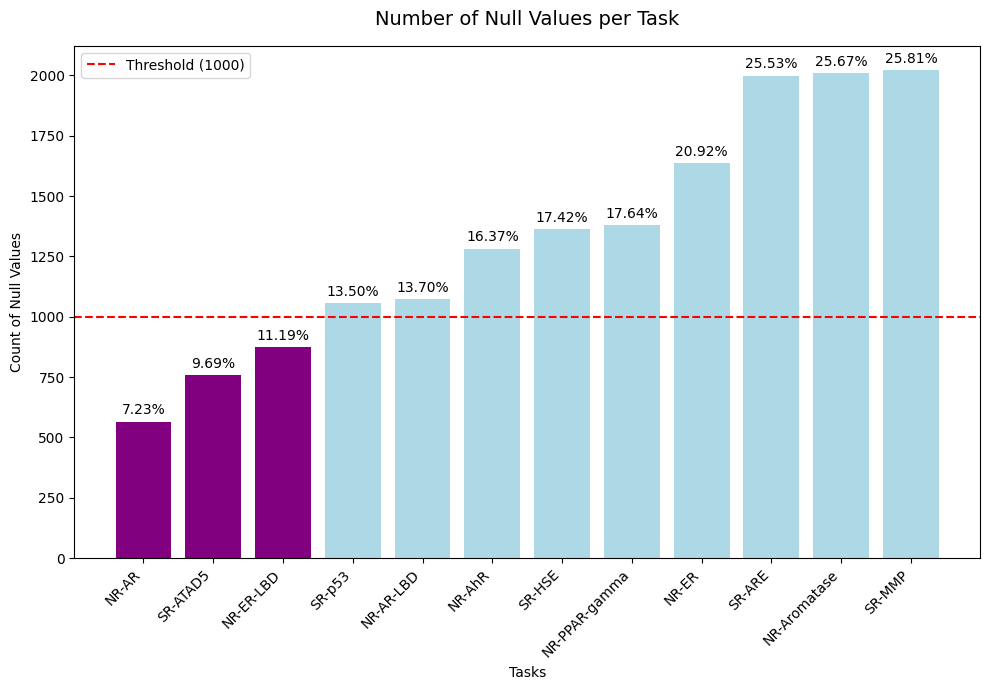

In [ ]:
# excluded mol_id and smiles
null_values =df.isna().sum().sort_values(ascending=True)[2:]
col_names =df.columns

null_bars, ax = plt.subplots(figsize=(10, 7))

threshold = 1000
total_rows = df.shape[0]

# Colors based on threshold
colors = [
    'purple' if v < threshold else 'lightblue'
    for v in null_values.values
]
bars = ax.bar(
    null_values.index,
    null_values.values,
    color=colors
)
labels = [
    f'{v / total_rows * 100:.2f}%'
    for v in null_values.values
]

ax.bar_label(
    bars,
    labels=labels,
    padding=3,
    fontsize=10
)
ax.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    label=f'Threshold ({threshold})'
)

ax.set_title(
    'Number of Null Values per Task',
    fontsize=14,
    pad=15
)
ax.set_ylabel('Count of Null Values')
ax.set_xlabel('Tasks')
plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)
ax.grid(False)
ax.legend()
null_bars.tight_layout()
plt.show()

In [ ]:
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0,0,1,<NA>,<NA>,0,0,1,0,0,0,0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0,0,0,0,0,0,0,<NA>,0,<NA>,0,0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,0,<NA>,<NA>,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0,0,0,0,0,0,0,<NA>,0,<NA>,0,0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0,0,0,0,0,0,0,0,0,0,0,0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


# Toxic Compounds in All Tasks

## Pie Plots

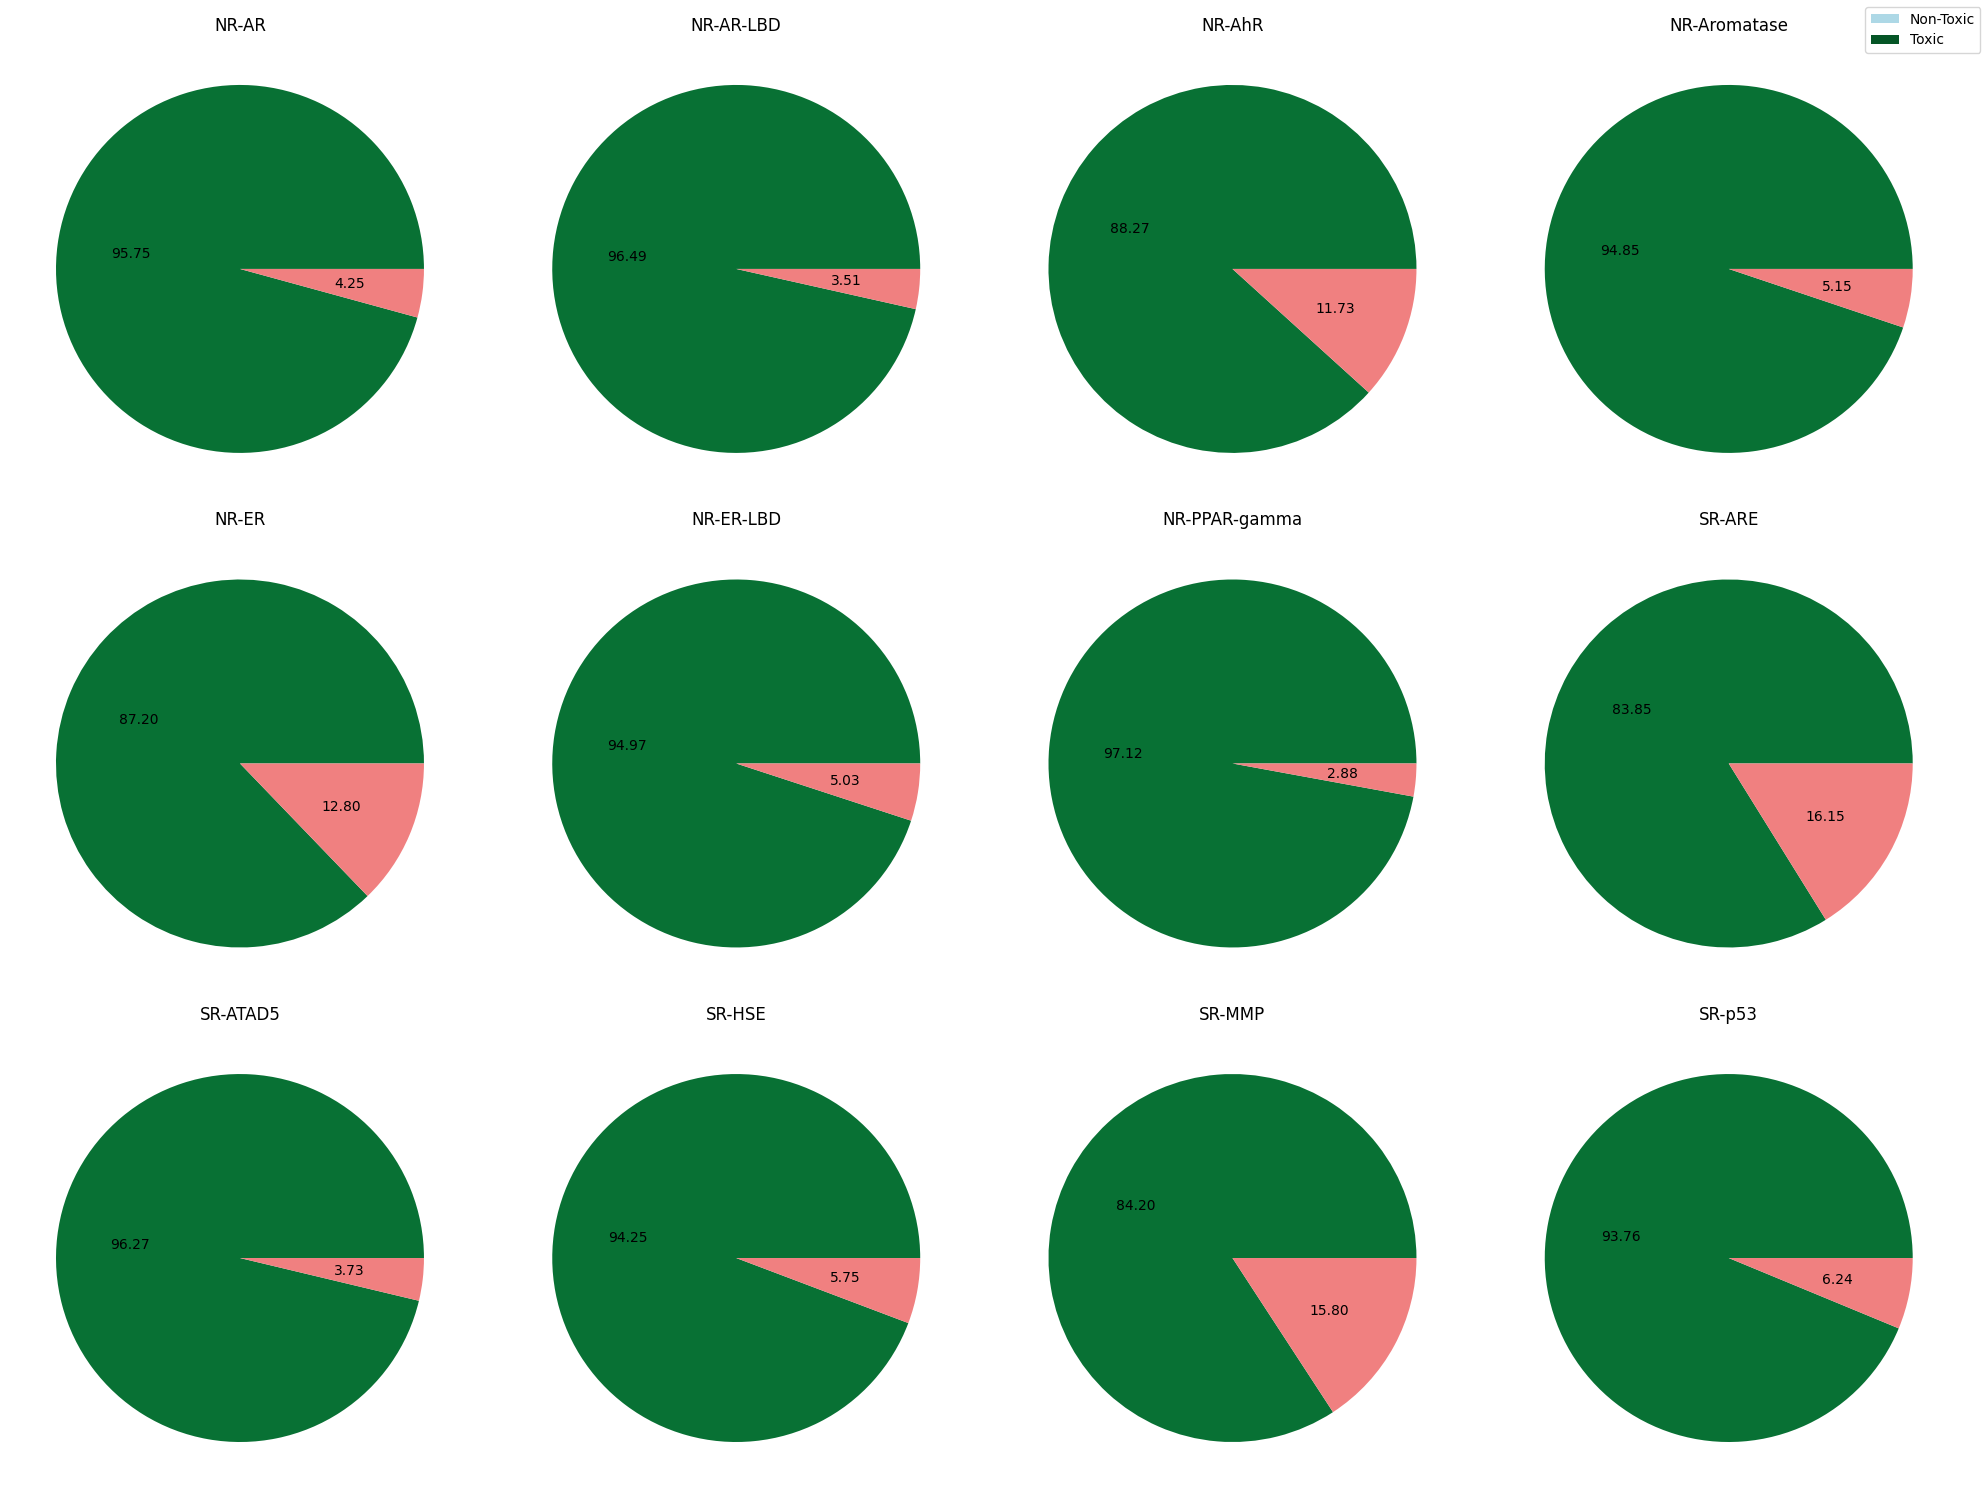

In [ ]:
# visualizing the toxic compounds per Task (which are all except the mol_id and smiles columns)
value_counts_dict = {task: df[task].value_counts() for task in task_columns}

from matplotlib.patches import Patch

pie_plot, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, task in enumerate(task_columns):
    ax = axes[i]

    value_counts_dict[task].plot.pie(
        ax=ax,
        autopct='%.2f',
        colors=["#087134", 'lightcoral'],
        labels=None  # Remove labels next to slices
    )

    ax.set_title(task)
    ax.set_ylabel('')

legend_handles = [
    Patch(facecolor='lightblue', label='Non-Toxic'),
    Patch(facecolor='#055526', label='Toxic')
]

pie_plot.legend(
    handles=legend_handles,
    loc='upper right',
    fontsize=10
)

pie_plot.tight_layout()
plt.show()

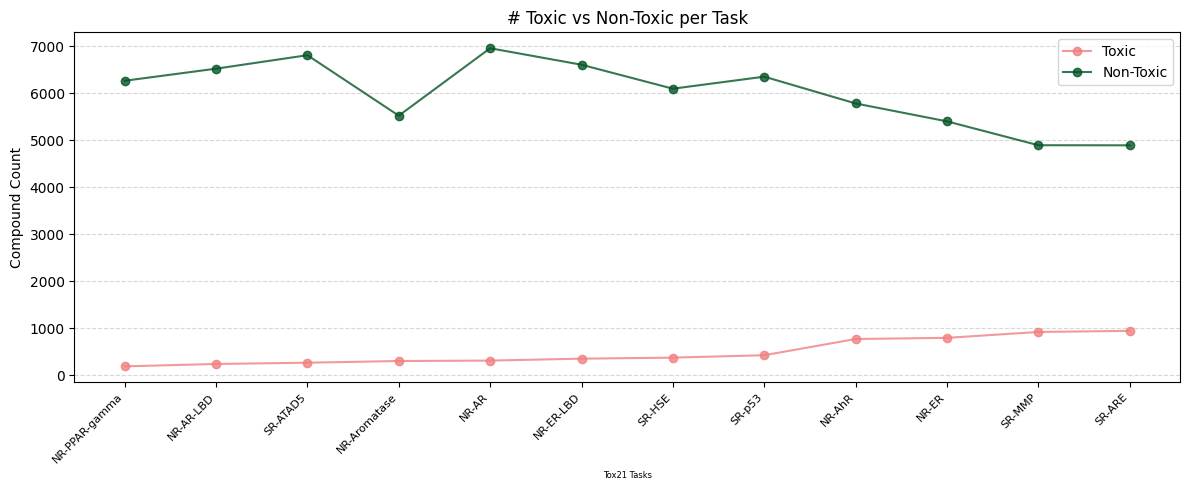

In [ ]:
tox_ntox_line, ax = plt.subplots(figsize=(12, 5))

# Count toxic and non-toxic compounds
toxic_df = pd.DataFrame({
    'toxic': (df[task_columns] == 1).sum(),
    'non_toxic': (df[task_columns] == 0).sum()
})

toxic_df_sorted = toxic_df.sort_values(by='toxic')

colors = {
    'toxic': "lightcoral",
    'non_toxic': "#055526"
}

toxic_df_sorted.plot(
    kind='line',
    ax=ax,
    color=[colors['toxic'], colors['non_toxic']],
    alpha=0.8
)

for line in ax.get_lines():
    line.set_marker('o')

ax.set_xticks(np.arange(len(toxic_df_sorted)))
ax.set_xticklabels(
    toxic_df_sorted.index,
    fontsize=8,
    rotation=45,
    ha='right'
)
ax.legend(['Toxic', 'Non-Toxic'], loc='upper right', fontsize=10)
ax.set_title('# Toxic vs Non-Toxic per Task', fontsize=12)
ax.set_ylabel('Compound Count', fontsize=10)
ax.set_xlabel('Tox21 Tasks', fontsize=6)
ax.grid(axis='y', linestyle='--', alpha=0.5)

tox_ntox_line.tight_layout()
plt.show()

In [ ]:
import rdkit.Chem as Chem
from rdkit.Chem import MolFromSmiles
from  rdkit.Chem.Scaffolds import MurckoScaffold
import random
def get_scaffold(smiles:str)->str:
    """
    Given a SMILES string, return its Murcko scaffold as a SMILES string.
    """
    mol = MolFromSmiles(smiles)
    if not mol:
        return ""
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

def scaffold_split(smiles_list, train_frac=0.6, val_frac=0.2, seed=42):
    scaffold_idx_dict = defaultdict(list)
    for idx,smi in enumerate(smiles_list):
        scaffold = get_scaffold(smi)
        scaffold_idx_dict[scaffold].append(idx)
    scaffold_groups =list(scaffold_idx_dict.values())
    rng = random.Random(seed)
    rng.shuffle(scaffold_groups)

    n_total = len(smiles_list)
    train_cutoff = int(train_frac * n_total)
    val_cutoff   = int((train_frac + val_frac) * n_total)
    train_idx, val_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) < train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(val_idx) < val_cutoff:
            val_idx.extend(group)
        else:
            test_idx.extend(group)
    print(f"Scaffold split → train: {len(train_idx)}, "
          f"val: {len(val_idx)}, test: {len(test_idx)}")
    return train_idx, val_idx, test_idx, scaffold_idx_dict


In [ ]:
from collections import defaultdict

train_idx, val_idx, test_idx, scaffold_idx_dict = scaffold_split(list(df["smiles"]))


[14:08:57] WARNING: not removing hydrogen atom without neighbors
[14:08:58] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:08:58] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:08:58] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:08:58] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:08:59] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:08:59] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:08:59] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:08:59] Explicit valence for atom # 20 Al, 6, is greater than permitted


Scaffold split → train: 4698, val: 2427, test: 706


In [ ]:
index_to_scaffold = {
    idx: scaf
    for scaf, indices in scaffold_idx_dict.items()
    for idx in indices
}


In [ ]:
df_scaffolds = df.drop(columns = 'mol_id').copy()
df_scaffolds['scaffolds'] = df_scaffolds.index.map(index_to_scaffold)
df_scaffolds['scaffolds']  = df_scaffolds['scaffolds'].astype('string')
df_scaffolds.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,smiles,scaffolds
0,0,0,1,<NA>,<NA>,0,0,1,0,0,0,0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,c1ccc2scnc2c1
1,0,0,0,0,0,0,0,<NA>,0,<NA>,0,0,CCN1C(=O)NC(c2ccccc2)C1=O,O=C1NC(=O)C(c2ccccc2)N1
2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,0,<NA>,<NA>,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,C1=C2CC[C@@H]3[C@H](CCC4CCC[C@H]43)[C@H]2CCC1
3,0,0,0,0,0,0,0,<NA>,0,<NA>,0,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,c1ccccc1
4,0,0,0,0,0,0,0,0,0,0,0,0,CC(O)(P(=O)(O)O)P(=O)(O)O,


In [ ]:
def smiles_to_mol(smile:str):
    if isinstance(smile, str) and smile:
        return Chem.MolFromSmiles(smile)
    return None

In [ ]:
df_mol_scaffold =df_scaffolds[['smiles', 'scaffolds']].copy()
df_mol_scaffold['mol_smiles'] = df_mol_scaffold['smiles'].apply(smiles_to_mol)
df_mol_scaffold['mol_scaffold'] = df_mol_scaffold['scaffolds'].apply(smiles_to_mol)
df_mol_scaffold = df_mol_scaffold.astype({'smiles': 'string', 'scaffolds': 'string'})

[14:09:00] WARNING: not removing hydrogen atom without neighbors
[14:09:00] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:09:00] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:09:00] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:09:00] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:09:00] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:09:00] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:09:01] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:09:01] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import HTML

def mol_to_svg(mol, width=200, height=150):
    """Converts RDKit Mol object to an inline HTML SVG string."""
    if mol is None:
        return ""
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

In [ ]:
df_mol_scaffold['img_smiles'] = df_mol_scaffold['mol_smiles'].apply(mol_to_svg)
df_mol_scaffold['img_scaffold'] = df_mol_scaffold['mol_scaffold'].apply(mol_to_svg)

In [ ]:
HTML(df_mol_scaffold[['smiles', 'img_smiles', 'scaffolds', 'img_scaffold']].head().to_html(escape=False))

In [ ]:
print(f"Unique Compounds: {df_mol_scaffold['smiles'].nunique()}" + "\n"+ \
     f"Unique Scaffolds: {df_mol_scaffold['scaffolds'].nunique()}")

Unique Compounds: 7831
Unique Scaffolds: 2404


Find out which and how many of those scaffolds are toxic

In [ ]:
df_mol_scaffold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   smiles        7831 non-null   string
 1   scaffolds     7831 non-null   string
 2   mol_smiles    7823 non-null   object
 3   mol_scaffold  6048 non-null   object
 4   img_smiles    7831 non-null   object
 5   img_scaffold  7831 non-null   object
dtypes: object(4), string(2)
memory usage: 367.2+ KB


In [ ]:
df_mol_scaffold['scaffolds'].value_counts().head(10)

,count
scaffolds,
,1783
c1ccccc1,1474
c1ccncc1,89
c1ccc(Cc2ccccc2)cc1,83
c1ccc2ccccc2c1,69
C1CCCCC1,63
c1c[nH+]c[nH]1,48
c1ccc(Oc2ccccc2)cc1,45
c1ccc(-c2ccccc2)cc1,40


In [ ]:
len(df_mol_scaffold[df_mol_scaffold['scaffolds']==''])

1783

In [ ]:
import random
from collections import defaultdict
from typing import Tuple, List, Union, Optional
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold


def _smiles_to_scaffold(smi: str) -> str:
    """Helper for parallel execution: Convert single SMILES to Murcko Scaffold SMILES."""
    if not isinstance(smi, str) or not smi:
        return ""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return ""
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return ""


def get_scaffolds_parallel(
    smiles_series: pd.Series,
    n_jobs: int = -1
) -> pd.Series:
    """
    Computes Murcko scaffolds for a Pandas Series of SMILES using parallel processing.
    """
    import os
    if n_jobs == -1:
        n_jobs = max(1, os.cpu_count() - 1)

    smiles_list = smiles_series.tolist()

    if n_jobs > 1:
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            scaffolds = list(executor.map(_smiles_to_scaffold, smiles_list, chunksize=500))
    else:
        scaffolds = [_smiles_to_scaffold(s) for s in smiles_list]

    return pd.Series(scaffolds, index=smiles_series.index, name="scaffold")


def scaffold_split(
    data: Union[pd.DataFrame, pd.Series, List[str]],
    smiles_col: Optional[str] = "smiles",
    train_frac: float = 0.8,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 42,
    n_jobs: int = -1,
    balanced: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    High-performance, Pythonic Bemis-Murcko scaffold splitter for pandas DataFrames/Series.

    Parameters
    ----------
    data : pd.DataFrame, pd.Series, or list
        Dataset containing SMILES strings.
    smiles_col : str, optional
        Name of column containing SMILES (if data is a DataFrame).
    train_frac : float
        Fraction of data for training.
    val_frac : float
        Fraction of data for validation.
    test_frac : float
        Fraction of data for testing.
    seed : int
        Random seed for shuffling equal-sized scaffold groups.
    n_jobs : int
        Number of CPU workers for parallel RDKit scaffold parsing (-1 uses all cores).
    balanced : bool
        If True, sorts scaffold clusters by size descending (Greedy Bin Packing),
        ensuring optimal split sizes.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray]
        Arrays of train, validation, and test indices.
    """
    assert np.isclose(train_frac + val_frac + test_frac, 1.0), "Splits must sum to 1.0"

    # Extract Series of SMILES
    if isinstance(data, pd.DataFrame):
        smiles_series = data[smiles_col]
    elif isinstance(data, list):
        smiles_series = pd.Series(data)
    else:
        smiles_series = data

    # 1. Parallel computation of scaffolds
    scaffolds = get_scaffolds_parallel(smiles_series, n_jobs=n_jobs)

    # 2. Group indices by scaffold using Pandas groupby (C-speed grouping)
    scaffold_to_indices = defaultdict(list)
    for idx, scaf in zip(smiles_series.index, scaffolds):
        scaffold_to_indices[scaf].append(idx)

    # 3. Sort scaffold clusters
    # Sorting by cluster size descending (Greedy Bin Packing) guarantees better split ratios
    if balanced:
        # Sort by size descending, then shuffle groups of identical size deterministically
        rng = random.Random(seed)
        scaffold_groups = list(scaffold_to_indices.values())
        rng.shuffle(scaffold_groups)
        scaffold_groups.sort(key=len, reverse=True)
    else:
        scaffold_groups = list(scaffold_to_indices.values())
        rng = random.Random(seed)
        rng.shuffle(scaffold_groups)

    # 4. Greedy assignment to train / val / test sets
    n_total = len(smiles_series)
    train_cutoff = train_frac * n_total
    val_cutoff = (train_frac + val_frac) * n_total

    train_idx, val_idx, test_idx = [], [], []

    for group in scaffold_groups:
        if len(train_idx) + len(group) <= train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(val_idx) + len(group) <= val_cutoff:
            val_idx.extend(group)
        else:
            test_idx.extend(group)

    print(f"Scaffold Split Completed ({n_total} total compounds):")
    print(f"  Train : {len(train_idx):>6d} ({len(train_idx)/n_total:.2%})")
    print(f"  Val   : {len(val_idx):>6d} ({len(val_idx)/n_total:.2%})")
    print(f"  Test  : {len(test_idx):>6d} ({len(test_idx)/n_total:.2%})")

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

In [ ]:
df['smiles'].describe()['top']

'O=C(O)Cc1cc(I)c(Oc2ccc(O)c(I)c2)c(I)c1'

In [ ]:
# TODO: chain the functions
value_counts_df = pd.DataFrame(value_counts_dict).T
value_counts_df.rename(columns={0: 'Non-Toxic', 1: 'Toxic'}, inplace=True)

value_counts_df['ratio'] = np.round(value_counts_df['Toxic'] / (value_counts_df['Toxic'] + value_counts_df['Non-Toxic']), 2)
value_counts_df.sort_values(by='ratio', ascending=False, inplace=True)
value_counts_df.head()


,Non-Toxic,Toxic,ratio
SR-MMP,4892,918,0.16
SR-ARE,4890,942,0.16
NR-ER,5400,793,0.13
NR-AhR,5781,768,0.12
SR-p53,6351,423,0.06


In [ ]:
# identify valid smiles
valid_mask = df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)

[14:09:21] WARNING: not removing hydrogen atom without neighbors
[14:09:21] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:09:21] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:09:22] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [ ]:
for k,v in value_counts_dict.items():
    print(f"Task: {k}, Non-Toxic: {v.get(0, 0)}, Toxic: {v.get(1, 0)}")

Task: NR-AR, Non-Toxic: 6956, Toxic: 309
Task: NR-AR-LBD, Non-Toxic: 6521, Toxic: 237
Task: NR-AhR, Non-Toxic: 5781, Toxic: 768
Task: NR-Aromatase, Non-Toxic: 5521, Toxic: 300
Task: NR-ER, Non-Toxic: 5400, Toxic: 793
Task: NR-ER-LBD, Non-Toxic: 6605, Toxic: 350
Task: NR-PPAR-gamma, Non-Toxic: 6264, Toxic: 186
Task: SR-ARE, Non-Toxic: 4890, Toxic: 942
Task: SR-ATAD5, Non-Toxic: 6808, Toxic: 264
Task: SR-HSE, Non-Toxic: 6095, Toxic: 372
Task: SR-MMP, Non-Toxic: 4892, Toxic: 918
Task: SR-p53, Non-Toxic: 6351, Toxic: 423


In [ ]:
null_values = pd.DataFrame(null_values, columns=['Null Count'])
null_values['null_percentage'] = np.round((null_values['Null Count'] / len(df)) * 100, 2)
null_values.head()

,Null Count,null_percentage
NR-AR,566,7.23
SR-ATAD5,759,9.69
NR-ER-LBD,876,11.19
SR-p53,1057,13.50
NR-AR-LBD,1073,13.70


In [ ]:
# merge null_values and value_counts_df based on the index (task names)
merged_summary = pd.merge(null_values, value_counts_df, left_index=True, right_index=True)
merged_summary.sort_values(by='Null Count', ascending=False, inplace=True)
merged_summary.head()

,Null Count,null_percentage,Non-Toxic,Toxic,ratio
SR-MMP,2021,25.81,4892,918,0.16
NR-Aromatase,2010,25.67,5521,300,0.05
SR-ARE,1999,25.53,4890,942,0.16
NR-ER,1638,20.92,5400,793,0.13
NR-PPAR-gamma,1381,17.64,6264,186,0.03


# Relationship of Null Values and Toxic Compounds per Task

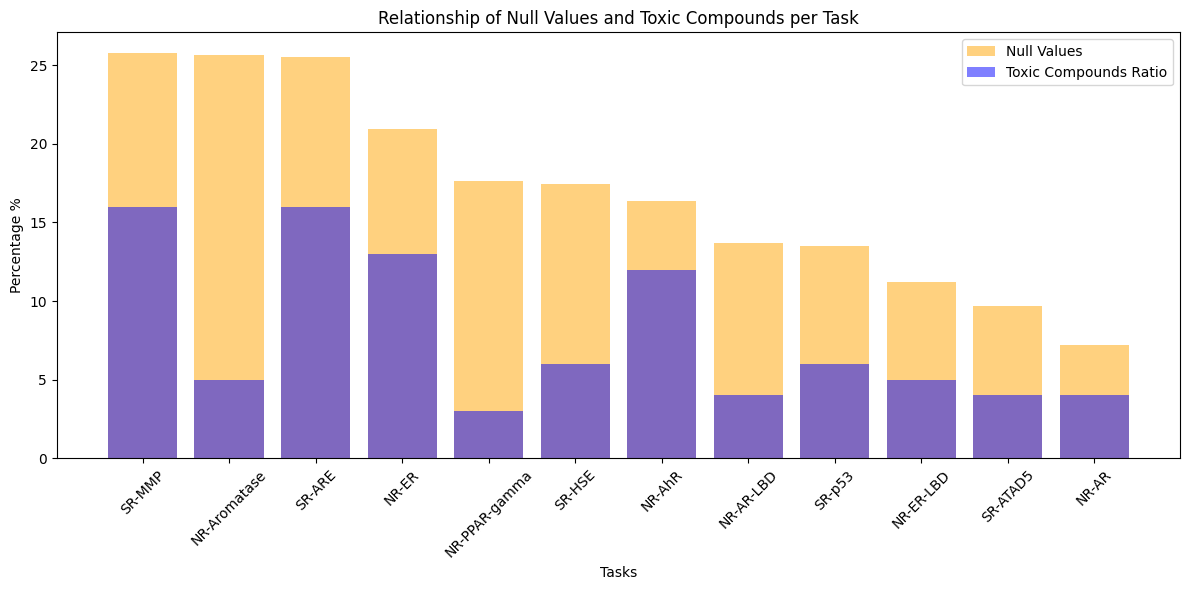

In [ ]:
plt.figure(figsize=(12, 6))
# plot bars null and toxic ratio on the same plot with different colors and a legend
plt.bar(merged_summary.index, merged_summary['null_percentage'],  color='orange', alpha=0.5, label='Null Values', )
plt.bar(merged_summary.index, merged_summary['ratio']*100, color='blue', alpha=0.5, label='Toxic Compounds Ratio')
plt.xlabel('Tasks')
plt.ylabel('Percentage %')
plt.title('Relationship of Null Values and Toxic Compounds per Task')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

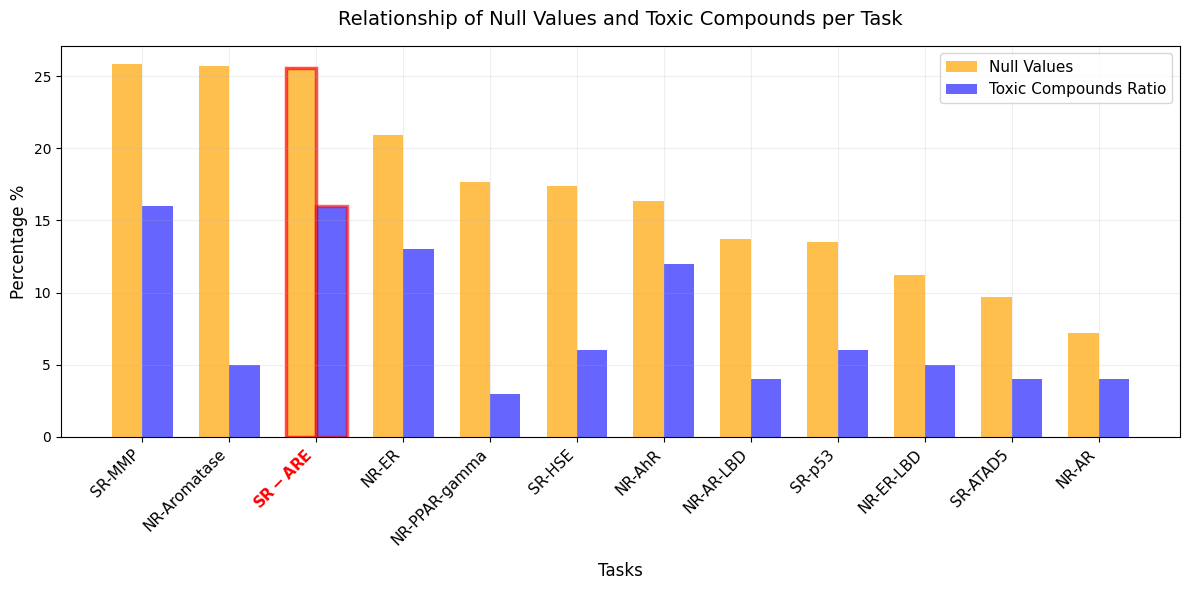

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup positions for side-by-side bars across all tasks
tasks = merged_summary.index
x = np.arange(len(tasks))
width = 0.35

# 2. Define custom edges and linewidths to highlight SR-ARE
edge_colors = ['red' if task == 'SR-ARE' else 'none' for task in tasks]
line_widths = [2.5 if task == 'SR-ARE' else 0 for task in tasks]

fig, ax = plt.subplots(figsize=(12, 6))
plt.grid(True, alpha  = 0.2)

# 3. Plot Null Values bars (side-by-side left offset)
rects1 = ax.bar(
    x - width / 2,
    merged_summary['null_percentage'],
    width,
    color='orange',
    alpha=0.7,
    label='Null Values',
    edgecolor=edge_colors,
    linewidth=line_widths,
)

# 4. Plot Toxic Compounds Ratio bars (side-by-side right offset)
rects2 = ax.bar(
    x + width / 2,
    merged_summary['ratio'] * 100,
    width,
    color='blue',
    alpha=0.6,
    label='Toxic Compounds Ratio',
    edgecolor=edge_colors,
    linewidth=line_widths,
)

# 5. Set axis labels and title
ax.set_xlabel('Tasks', fontsize=12, labelpad=10)
ax.set_ylabel('Percentage %', fontsize=12)
ax.set_title(
    'Relationship of Null Values and Toxic Compounds per Task',
    fontsize=14,
    pad=15,
)
ax.set_xticks(x)

# 6. Make ONLY 'SR-ARE' tick label bold
tick_labels = [
    r'$\mathbf{SR-ARE}$' if task == 'SR-ARE' else task for task in tasks
]
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=11)

# Format highlighted label color separately if desired
for label in ax.get_xticklabels():
    if 'SR-ARE' in label.get_text():
        label.set_color('red')

ax.legend(fontsize=11)
plt.tight_layout()
plt_fname = os.path.join(ANALYSIS_DIR, f'per_task_null_toxic.pdf')
plt.savefig(plt_fname, format = 'pdf', bbox = 'tight')
plt.show()

# TOX3GNN_SRARE.ipynb Results
Optuna + Scaffold Hopping

In [ ]:
print()

In [6]:
import csv, json
TASK_NAME ='SR-ARE'
RESULT_DIR = f'{DRIVE_ROOT}/{TASK_NAME}/results_tox21'

csv_fname =os.path.join(RESULT_DIR, f'{TASK_NAME}_runs_summary.csv')
results_df =None
if not os.path.exists(csv_fname):
    print(f'No summary {csv_fname}')
else:
  results_df = pd.read_csv(csv_fname)
results_df.head()


,task,model,run,test_auc,best_val_auc,train_loss_history,val_auc_history
0,SR-ARE,sage_gin_gin,0,0.812593,0.781736,"[1.069044, 0.968899, 0.918976, 0.89468, 0.8664...","[0.778373, 0.781736, 0.779214, 0.758601, 0.772..."
1,SR-ARE,sage_gin_gin,1,0.798979,0.801148,"[1.063783, 0.974297, 0.942866, 0.897307, 0.843...","[0.782145, 0.801148, 0.78128, 0.774962, 0.7962..."
2,SR-ARE,sage_gin_gin,2,0.791516,0.800043,"[1.072718, 0.986954, 0.938284, 0.885896, 0.865...","[0.78695, 0.800043, 0.774938, 0.797713, 0.7866..."
3,SR-ARE,sage_gin_gin,3,0.807453,0.807179,"[1.078124, 0.991736, 0.931379, 0.902055, 0.855...","[0.789761, 0.807179, 0.760955, 0.771214, 0.788..."
4,SR-ARE,sage_gin_gin,4,0.782416,0.800091,"[1.05164, 0.971006, 0.918029, 0.89026, 0.85015...","[0.77967, 0.787743, 0.798722, 0.791418, 0.7764..."


In [8]:
results_df.shape

(10, 7)

Sorting by test AUC

In [11]:
results_df_sorted =results_df.sort_values(by='test_auc', ascending=False)
best_run = results_df.iloc[0]

Getting the best run

In [13]:
best_run

,0
task,SR-ARE
model,sage_gin_gin
run,0
test_auc,0.812593
best_val_auc,0.781736
train_loss_history,"[1.069044, 0.968899, 0.918976, 0.89468, 0.8664..."
val_auc_history,"[0.778373, 0.781736, 0.779214, 0.758601, 0.772..."


In [14]:
results_df_sorted

,task,model,run,test_auc,best_val_auc,train_loss_history,val_auc_history
0,SR-ARE,sage_gin_gin,0,0.812593,0.781736,"[1.069044, 0.968899, 0.918976, 0.89468, 0.8664...","[0.778373, 0.781736, 0.779214, 0.758601, 0.772..."
3,SR-ARE,sage_gin_gin,3,0.807453,0.807179,"[1.078124, 0.991736, 0.931379, 0.902055, 0.855...","[0.789761, 0.807179, 0.760955, 0.771214, 0.788..."
1,SR-ARE,sage_gin_gin,1,0.798979,0.801148,"[1.063783, 0.974297, 0.942866, 0.897307, 0.843...","[0.782145, 0.801148, 0.78128, 0.774962, 0.7962..."
8,SR-ARE,sage_gin_gin,8,0.792395,0.795503,"[1.062141, 0.977766, 0.942262, 0.884637, 0.865...","[0.795503, 0.780175, 0.768427, 0.778277, 0.773..."
2,SR-ARE,sage_gin_gin,2,0.791516,0.800043,"[1.072718, 0.986954, 0.938284, 0.885896, 0.865...","[0.78695, 0.800043, 0.774938, 0.797713, 0.7866..."
6,SR-ARE,sage_gin_gin,6,0.785341,0.798482,"[1.062135, 0.986825, 0.92563, 0.88545, 0.89574...","[0.763382, 0.798482, 0.775538, 0.789208, 0.767..."
4,SR-ARE,sage_gin_gin,4,0.782416,0.800091,"[1.05164, 0.971006, 0.918029, 0.89026, 0.85015...","[0.77967, 0.787743, 0.798722, 0.791418, 0.7764..."
7,SR-ARE,sage_gin_gin,7,0.782043,0.805809,"[1.074161, 0.979537, 0.939049, 0.878532, 0.855...","[0.805809, 0.791226, 0.785893, 0.786758, 0.787..."
5,SR-ARE,sage_gin_gin,5,0.763855,0.801701,"[1.05984, 0.976096, 0.936767, 0.894413, 0.8485...","[0.796103, 0.779502, 0.781616, 0.795911, 0.797..."
9,SR-ARE,sage_gin_gin,9,0.749976,0.801725,"[1.094452, 0.974922, 0.931762, 0.882849, 0.860...","[0.794133, 0.799995, 0.792812, 0.783634, 0.785..."


#plotting best Val AUC and Test AUC

In [19]:
# create a per run best_val_auc and auc graph


Based on the visualization we see no consisteny but we should compare the results with the prediction-imputed version

Questions?
## Feature Correlation
Which features are more important for toxicity prediction?
(feature correlation, PCA)
Which column has the largest sum of toxicity

## Fragmentation
How to identify the toxic fragments per column

## Toxicity
Run pIC50 , etc tests to filter out the molecules
that are inherently toxic ( remove them if they are
the minority)
Filters
Ashford/Brenk alerts or REOS filters (for general reactivity/toxicity).

Pain/Pan-Assay Interference Compounds (PAINS): Identifies molecules that falsely interfere with assay readouts rather than causing real biological toxicity.